In [21]:
# ---- IMPORTS -----


# --- Core Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Statistics ---
from scipy import stats

# --- Settings ---
import warnings
warnings.filterwarnings('ignore')

# --- Pandas Display Settings ---
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

In [22]:
# LOAD DATA

# --- Load Datasets ---
df = pd.read_csv("clean_events.csv")
features_master = pd.read_csv("features_master.csv")
session_features = pd.read_csv("session_features.csv")

# --- Quick Shape Check ---
print("Events shape         :", df.shape)
print("Features shape       :", features_master.shape)
print("Session shape        :", session_features.shape)

Events shape         : (2755641, 12)
Features shape       : (1407580, 29)
Session shape        : (1761675, 16)


In [23]:
# ----- FIX DATA TYPES -------

# Convert datetime
df['event_datetime'] = pd.to_datetime(df['event_datetime'], format='mixed')

# Check timezone
if df['event_datetime'].dt.tz is not None: df['event_datetime'] = df['event_datetime'].dt.tz_convert(None)

# Convert IDs to string
df['visitorid']  = df['visitorid'].astype(str)
df['session_id'] = df['session_id'].astype(str)
df['itemid']     = df['itemid'].astype(str)

# Verify
print(df.dtypes)

visitorid                    str
session_id                   str
session_num                int64
event_type                   str
itemid                       str
transactionid            float64
event_datetime    datetime64[us]
hour_of_day                int64
day_of_week                int64
is_weekend                 int64
categoryid                 int64
available                  int64
dtype: object


In [24]:
# --- SECTION 1: BASIC DISTRIBUTION STATS ---

# Views per user
print("--- Views per User ---")
print(features_master['total_views'].describe())

# Sessions per user
print("\n--- Sessions per User ---")
print(features_master['total_sessions'].describe())

# Events per session
print("\n--- Events per Session ---")
print(session_features['events_per_session'].describe())

# Session duration
print("\n--- Session Duration (mins) ---")
print(session_features['session_duration_mins'].describe())

# Time gap between visits
print("\n--- Days Since Last Visit ---")
print(features_master['days_since_last_visit'].describe())

--- Views per User ---
count    1.407580e+06
mean     1.892765e+00
std      1.099361e+01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      6.479000e+03
Name: total_views, dtype: float64

--- Sessions per User ---
count    1.407580e+06
mean     1.251563e+00
std      1.818195e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.620000e+02
Name: total_sessions, dtype: float64

--- Events per Session ---
count    1.761675e+06
mean     1.564216e+00
std      2.599172e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.170000e+02
Name: events_per_session, dtype: float64

--- Session Duration (mins) ---
count    1.761675e+06
mean     1.754057e+00
std      8.325496e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.284041e+02
Name: session_duration_mins, dtype: float64

--- Days Since Last Visit --

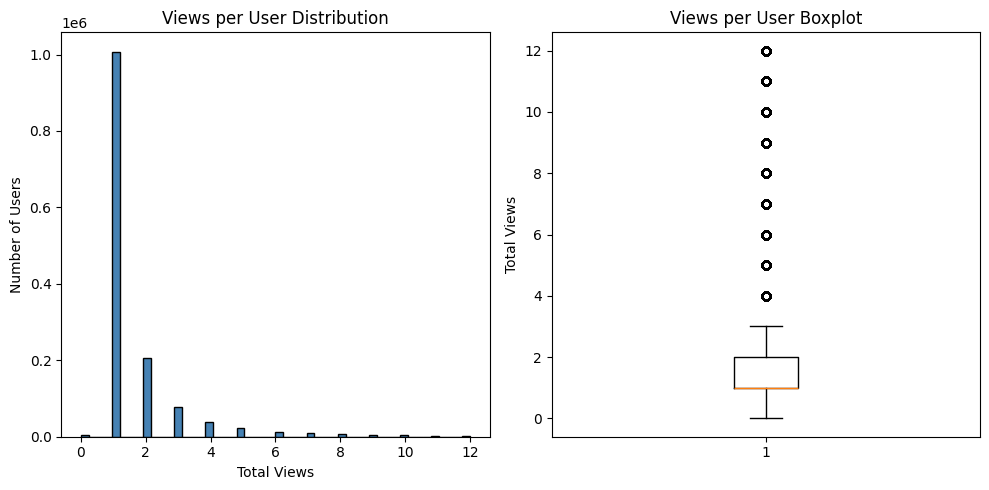

99th percentile views : 12
Mean views            : 1.89
Median views          : 1.00


In [25]:
# --- SECTION 2: VIEWS PER USER DISTRIBUTION ----

# --- Remove Extreme Outliers for Visualization ---
views_data = features_master['total_views']
views_cap = views_data.quantile(0.99)
views_plot = views_data[views_data <= views_cap]

# --- Plotting Figure ---
plt.figure(figsize=(10, 5))

# --- Histogram ---
plt.subplot(1, 2, 1)
plt.hist(views_plot, bins=50, color='steelblue', edgecolor='black')
plt.title('Views per User Distribution')
plt.xlabel('Total Views')
plt.ylabel('Number of Users')

# --- Boxplot ---
plt.subplot(1, 2, 2)
plt.boxplot(views_plot)
plt.title('Views per User Boxplot')
plt.ylabel('Total Views')

# --- Layout & Save ---
plt.tight_layout()
plt.savefig('views_per_user_distribution.png', dpi=150)
plt.show()

# --- Summary Statistics ---
print(f"99th percentile views : {views_cap:.0f}")
print(f"Mean views            : {views_data.mean():.2f}")
print(f"Median views          : {views_data.median():.2f}")

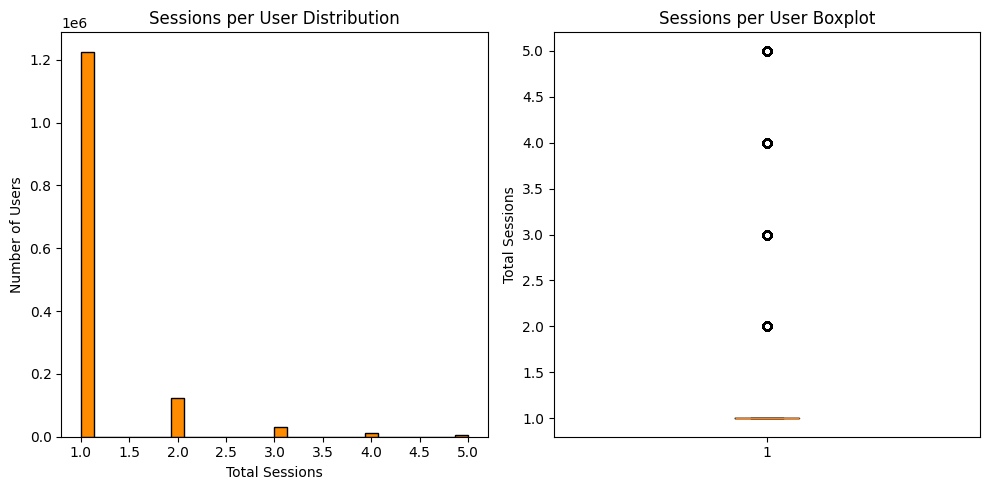

99th percentile sessions : 5
Mean sessions            : 1.25
Median sessions          : 1.00


In [26]:
# ---- SECTION 2 CONTINUED: SESSIONS PER USER DISTRIBUTION----- 

# --- Remove Extreme Outliers for Visualization ---
sessions_data = features_master['total_sessions']
sessions_cap = sessions_data.quantile(0.99)
sessions_plot = sessions_data[sessions_data <= sessions_cap]

# --- Plotting Figure ---
plt.figure(figsize=(10, 5))

# --- Histogram ---
plt.subplot(1, 2, 1)
plt.hist(sessions_plot, bins=30, color='darkorange', edgecolor='black')
plt.title('Sessions per User Distribution')
plt.xlabel('Total Sessions')
plt.ylabel('Number of Users')

# --- Boxplot ---
plt.subplot(1, 2, 2)
plt.boxplot(sessions_plot)
plt.title('Sessions per User Boxplot')
plt.ylabel('Total Sessions')

# --- Layout & Save ---
plt.tight_layout()
plt.savefig('sessions_per_user_distribution.png', dpi=150)
plt.show()

# --- Summary Statistics ---
print(f"99th percentile sessions : {sessions_cap:.0f}")
print(f"Mean sessions            : {sessions_data.mean():.2f}")
print(f"Median sessions          : {sessions_data.median():.2f}")

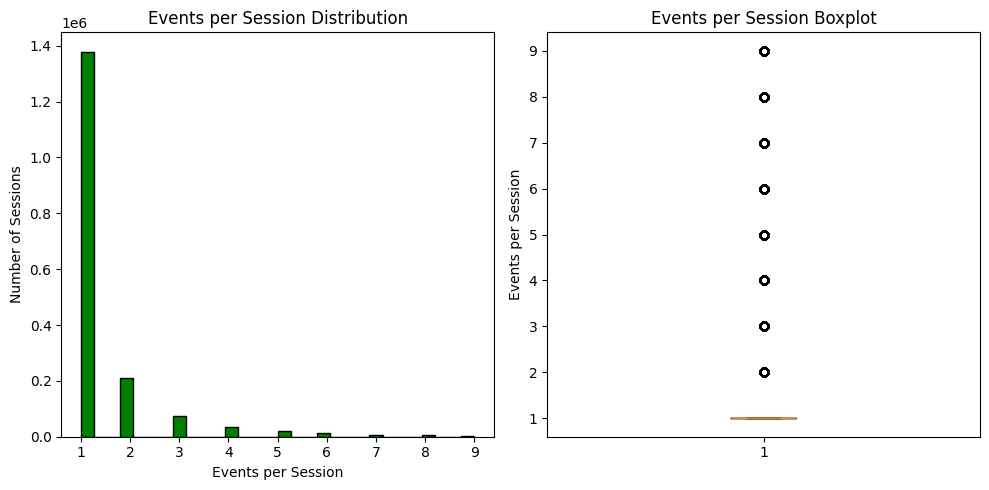

99th percentile events : 9
Mean events/session    : 1.56
Median events/session  : 1.00


In [27]:
# SECTION 2 CONTINUED: EVENTS PER SESSION DISTRIBUTION

# --- Remove Extreme Outliers for Visualization ---
events_data = session_features['events_per_session']
events_cap = events_data.quantile(0.99)
events_plot = events_data[events_data <= events_cap]

# --- Plotting Figure ---
plt.figure(figsize=(10, 5))

# --- Histogram ---
plt.subplot(1, 2, 1)
plt.hist(events_plot, bins=30, color='green', edgecolor='black')
plt.title('Events per Session Distribution')
plt.xlabel('Events per Session')
plt.ylabel('Number of Sessions')

# --- Boxplot ---
plt.subplot(1, 2, 2)
plt.boxplot(events_plot)
plt.title('Events per Session Boxplot')
plt.ylabel('Events per Session')

# --- Layout & Save ---
plt.tight_layout()
plt.savefig('events_per_session_distribution.png', dpi=150)
plt.show()

# --- Summary Statistics ---
print(f"99th percentile events : {events_cap:.0f}")
print(f"Mean events/session    : {events_data.mean():.2f}")
print(f"Median events/session  : {events_data.median():.2f}")

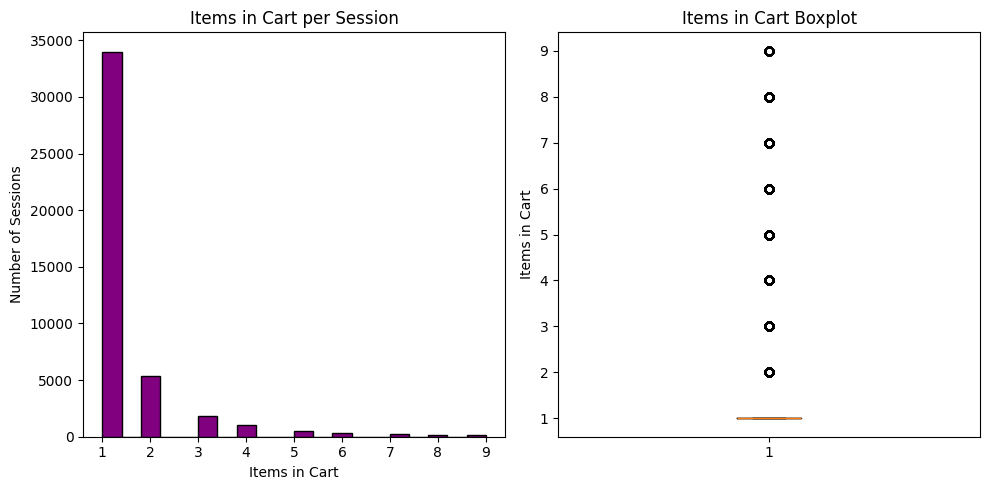

Total sessions with cart : 43,924
Mean items in cart       : 1.57
Median items in cart     : 1.00


In [28]:
# SECTION 2 CONTINUED: ITEMS IN CART PER SESSION

# --- Cart Items per Session ---
cart_per_session = (
    df[df['event_type'] == 'addtocart']
    .groupby('session_id')['itemid']
    .count()
    .reset_index()
    .rename(columns={'itemid': 'items_in_cart'})
)

# --- Data Preparation ---
cart_data = cart_per_session['items_in_cart']
cart_cap = cart_data.quantile(0.99)
cart_plot = cart_data[cart_data <= cart_cap]

# --- Plotting Figure ---
plt.figure(figsize=(10, 5))

# --- Histogram ---
plt.subplot(1, 2, 1)
plt.hist(cart_plot, bins=20, color='purple', edgecolor='black')
plt.title('Items in Cart per Session')
plt.xlabel('Items in Cart')
plt.ylabel('Number of Sessions')

# --- Boxplot ---
plt.subplot(1, 2, 2)
plt.boxplot(cart_plot)
plt.title('Items in Cart Boxplot')
plt.ylabel('Items in Cart')

# --- Layout & Save ---
plt.tight_layout()
plt.savefig('items_in_cart_distribution.png', dpi=150)
plt.show()

# --- Summary Statistics ---
print(f"Total sessions with cart : {len(cart_data):,}")
print(f"Mean items in cart       : {cart_data.mean():.2f}")
print(f"Median items in cart     : {cart_data.median():.2f}")

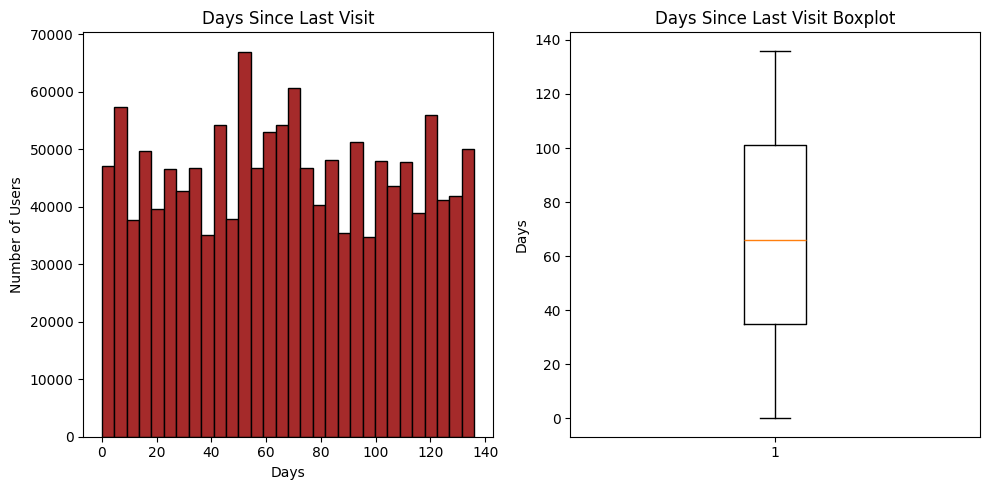

Mean days since last visit   : 67.90
Median days since last visit : 67.00


In [29]:
# SECTION 2 CONTINUED: TIME GAP BETWEEN VISITS


gap_data = features_master['days_since_last_visit']
gap_cap  = gap_data.quantile(0.99)
gap_plot = gap_data[gap_data <= gap_cap]

plt.figure(figsize=(10, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(gap_plot, bins=30, color='brown', edgecolor='black')
plt.title('Days Since Last Visit')
plt.xlabel('Days')
plt.ylabel('Number of Users')

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(gap_plot, vert=True)
plt.title('Days Since Last Visit Boxplot')
plt.ylabel('Days')

plt.tight_layout()
plt.savefig('time_gap_distribution.png', dpi=150)
plt.show()

print(f"Mean days since last visit   : {gap_data.mean():.2f}")
print(f"Median days since last visit : {gap_data.median():.2f}")

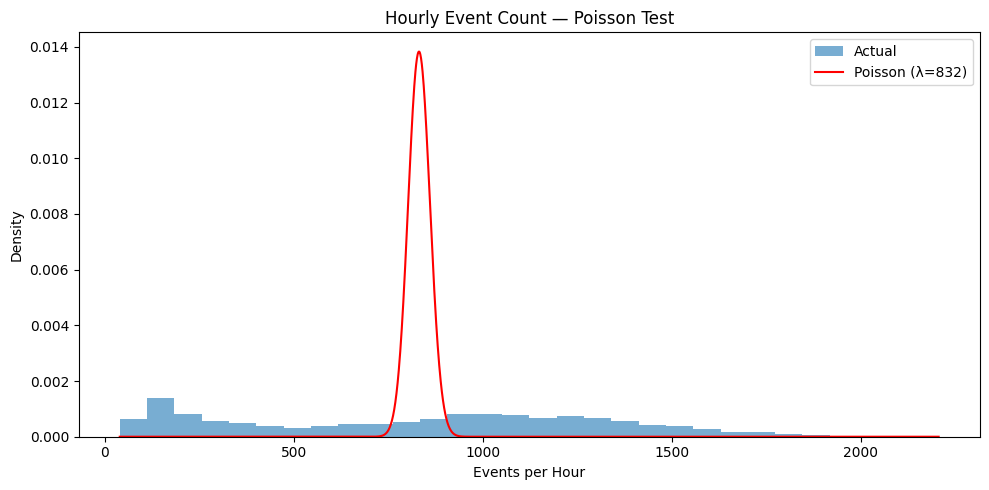

POISSON TEST RESULTS
Lambda: 832.02
KS Statistic: 0.4888
P-Value: 0.0
Conclusion: Not Poisson


In [30]:
# ============================================================
# SECTION 3: POISSON TEST (HOURLY EVENTS)
# ============================================================

# --- Hourly event counts ---
hourly_data = df.groupby(df['event_datetime'].dt.floor('h')).size()
# --- Poisson mean ---
lam = hourly_data.mean()
# --- KS test ---
ks_stat, ks_p = stats.kstest(hourly_data, 'poisson', args=(lam,))
# --- Plot ---
plt.figure(figsize=(10, 5))
plt.hist(hourly_data, bins=30, density=True, alpha=0.6, label='Actual')

x = np.arange(hourly_data.min(), hourly_data.max())
plt.plot(x, stats.poisson.pmf(x, lam), 'r-', label=f'Poisson (λ={lam:.0f})')

plt.title('Hourly Event Count — Poisson Test')
plt.xlabel('Events per Hour')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.savefig('poisson_test.png', dpi=150)
plt.show()

# --- Result ---
print("=" * 50)
print("POISSON TEST RESULTS")
print("=" * 50)
print("Lambda:", round(lam, 2))
print("KS Statistic:", round(ks_stat, 4))
print("P-Value:", round(ks_p, 4))

if ks_p < 0.05:
    print("Conclusion: Not Poisson")
else:
    print("Conclusion: Poisson fits")

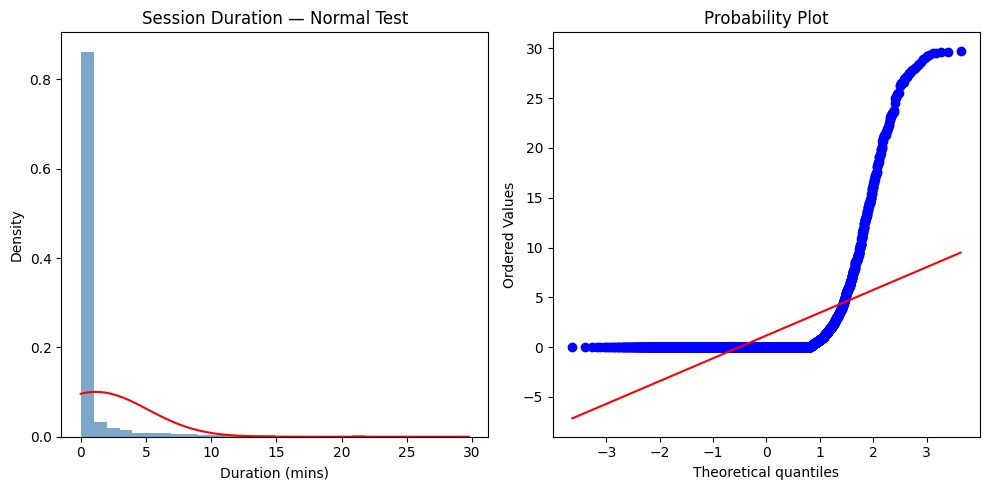

SHAPIRO-WILK TEST
Sample size: 5000
Mean: 1.17
Std: 3.98
W: 0.3314
P-value: 0.0
Conclusion: Not normal


In [31]:
# SECTION 3 CONTINUED: NORMAL TEST (SIMPLIFIED)

# --- Clean session duration ---
dur = session_features['session_duration_mins'].dropna()
dur = dur[dur <= dur.quantile(0.99)]
# --- Sample data (for test speed) ---
sample = dur.sample(min(5000, len(dur)), random_state=42)
# --- Shapiro test ---
w_stat, p_val = stats.shapiro(sample)
# --- Plot ---
plt.figure(figsize=(10, 5))

# Histogram + normal curve
plt.subplot(1, 2, 1)
plt.hist(sample, bins=30, density=True, alpha=0.7, color='steelblue')

mu, sigma = sample.mean(), sample.std()
x = np.linspace(sample.min(), sample.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-')

plt.title('Session Duration — Normal Test')
plt.xlabel('Duration (mins)')
plt.ylabel('Density')

# Q-Q plot
plt.subplot(1, 2, 2)
stats.probplot(sample, dist='norm', plot=plt)

plt.tight_layout()
plt.savefig('normal_test.png', dpi=150)
plt.show()

# --- Result ---
print("=" * 50)
print("SHAPIRO-WILK TEST")
print("=" * 50)
print("Sample size:", len(sample))
print("Mean:", round(mu, 2))
print("Std:", round(sigma, 2))
print("W:", round(w_stat, 4))
print("P-value:", round(p_val, 4))

if p_val < 0.05:
    print("Conclusion: Not normal")
else:
    print("Conclusion: Normal")

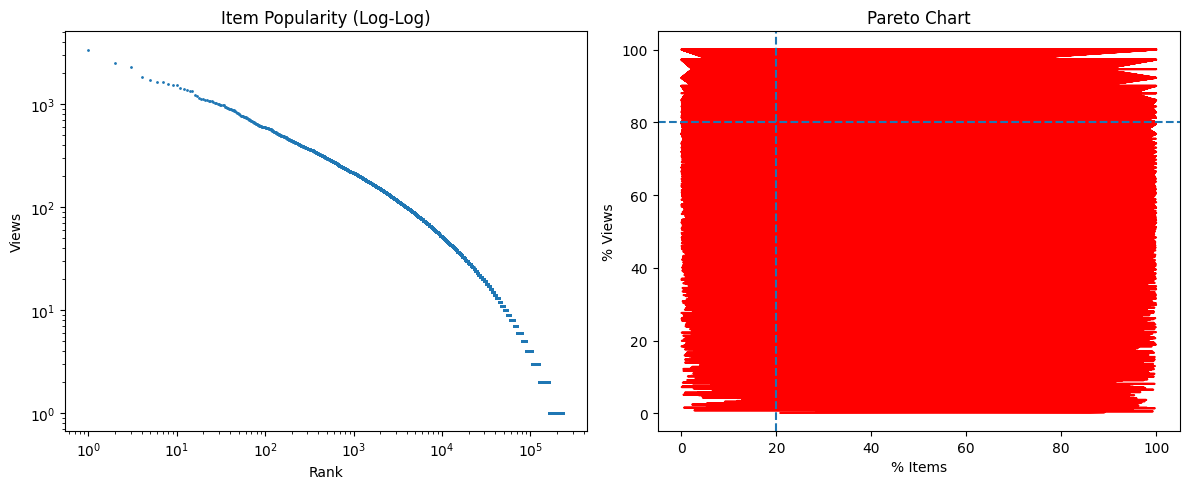

PARETO CHECK
Total items: 234838
Top 20% views: 78.3 %
Result: Pareto holds


In [32]:
# --- SECTION 3 CONTINUED: POWER LAW TEST ---

# --- Item view counts ---
item_views = (
    df[df['event_type'] == 'view']
    .groupby('itemid')
    .size()
    .sort_values(ascending=False)
)

# --- Pareto calculation ---
total_views = item_views.sum()
total_items = len(item_views)

top_20 = int(total_items * 0.2)
top_20_views = item_views.head(top_20).sum()
top_20_pct = (top_20_views / total_views) * 100

# --- Plot ---
plt.figure(figsize=(12, 5))

# Log-log plot
plt.subplot(1, 2, 1)
plt.loglog(range(1, len(item_views) + 1), item_views.values, '.', markersize=2)
plt.title('Item Popularity (Log-Log)')
plt.xlabel('Rank')
plt.ylabel('Views')

# Pareto curve
cum_pct = item_views.cumsum() / total_views * 100
item_pct = (item_views.index.to_series().rank(method='first') / total_items) * 100

plt.subplot(1, 2, 2)
plt.plot(item_pct, cum_pct, color='red')
plt.axvline(20, linestyle='--')
plt.axhline(80, linestyle='--')
plt.title('Pareto Chart')
plt.xlabel('% Items')
plt.ylabel('% Views')

plt.tight_layout()
plt.savefig('power_law_pareto.png', dpi=150)
plt.show()

# --- Result ---
print("=" * 50)
print("PARETO CHECK")
print("=" * 50)
print("Total items:", total_items)
print("Top 20% views:", round(top_20_pct, 2), "%")

if top_20_pct >= 70:
    print("Result: Pareto holds")
else:
    print("Result: Pareto weak")

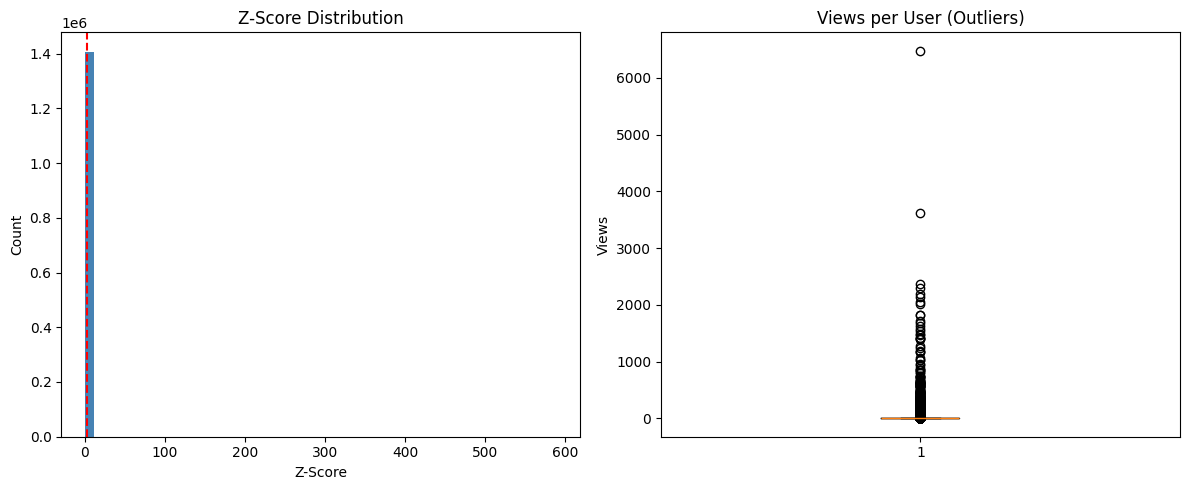

OUTLIER RESULTS
Total users: 1407580

Z-score outliers: 2122
Z-score %: 0.15

IQR outliers: 113451
IQR %: 8.06


In [33]:

# --- SECTION 4: OUTLIER DETECTION ---

# --- Data ---
views = features_master['total_views']

# --- Z-score method ---
z = np.abs(stats.zscore(views))
out_z = features_master[z > 3]

# --- IQR method ---
q1, q3 = views.quantile([0.25, 0.75])
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

out_iqr = features_master[(views < lower) | (views > upper)]

# --- Flag outliers ---
features_master['is_outlier_z'] = (z > 3).astype(int)
features_master['is_outlier_iqr'] = ((views < lower) | (views > upper)).astype(int)

# --- Plot ---
plt.figure(figsize=(12, 5))

# Z-score
plt.subplot(1, 2, 1)
plt.hist(z, bins=50, color='steelblue')
plt.axvline(3, color='red', linestyle='--')
plt.title('Z-Score Distribution')
plt.xlabel('Z-Score')
plt.ylabel('Count')

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(views)

plt.title('Views per User (Outliers)')
plt.ylabel('Views')

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150)
plt.show()

# --- Results ---
print("=" * 50)
print("OUTLIER RESULTS")
print("=" * 50)
print("Total users:", len(features_master))

print("\nZ-score outliers:", len(out_z))
print("Z-score %:", round(len(out_z)/len(features_master)*100, 2))

print("\nIQR outliers:", len(out_iqr))
print("IQR %:", round(len(out_iqr)/len(features_master)*100, 2))

In [35]:
# SECTION 5: EXPORT RESULTS 

# --- Recalculate missing variables if needed ---

# Poisson values (if not defined)
hourly_data = df.groupby(df['event_datetime'].dt.floor('h')).size()
lambda_poisson = hourly_data.mean()
ks_stat, ks_pvalue = stats.kstest(hourly_data, 'poisson', args=(lambda_poisson,))

# Shapiro (safe recompute)
session_dur = session_features['session_duration_mins'].dropna()
session_dur = session_dur[session_dur <= session_dur.quantile(0.99)]
sample = session_dur.sample(min(5000, len(session_dur)), random_state=42)
shapiro_stat, shapiro_pvalue = stats.shapiro(sample)

# Item Pareto (safe recompute)
item_views = (
    df[df['event_type'] == 'view']
    .groupby('itemid')
    .size()
)

top_20_items = int(len(item_views) * 0.2)
top_20_pct = (item_views.head(top_20_items).sum() / item_views.sum()) * 100

# Outliers (safe recompute)
views = features_master['total_views']
z = np.abs(stats.zscore(views))
outliers_zscore = features_master[z > 3]
outliers_iqr = features_master[(views < views.quantile(0.25) - 1.5*(views.quantile(0.75)-views.quantile(0.25))) |
                               (views > views.quantile(0.75) + 1.5*(views.quantile(0.75)-views.quantile(0.25)))]

# --- Build summary ---
dist_summary = pd.DataFrame({
    'metric': [
        'mean_views_per_user',
        'median_views_per_user',
        'mean_sessions_per_user',
        'median_sessions_per_user',
        'mean_events_per_session',
        'median_events_per_session',
        'poisson_lambda',
        'poisson_ks_pvalue',
        'shapiro_pvalue',
        'top_20pct_items_view_share',
        'zscore_outlier_count',
        'iqr_outlier_count'
    ],
    'value': [
        features_master['total_views'].mean(),
        features_master['total_views'].median(),
        features_master['total_sessions'].mean(),
        features_master['total_sessions'].median(),
        session_features['events_per_session'].mean(),
        session_features['events_per_session'].median(),
        lambda_poisson,
        ks_pvalue,
        shapiro_pvalue,
        top_20_pct,
        len(outliers_zscore),
        len(outliers_iqr)
    ]
})

# --- Save ---
dist_summary.to_csv("distribution_results.csv", index=False)

print("Saved successfully:", len(dist_summary), "metrics")
dist_summary


Saved successfully: 12 metrics


,metric,value
0,mean_views_per_user,1.892765e+00
1,median_views_per_user,1.000000e+00
2,mean_sessions_per_user,1.251563e+00
3,median_sessions_per_user,1.000000e+00
4,mean_events_per_session,1.564216e+00
5,median_events_per_session,1.000000e+00
6,poisson_lambda,8.320172e+02
7,poisson_ks_pvalue,0.000000e+00
8,shapiro_pvalue,1.469913e-86
9,top_20pct_items_view_share,1.936617e+01
